In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns


# Set a clean, professional style for all charts
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['grid.linestyle'] = '--'


In [5]:
# Load clean dataset
df = pd.read_csv('rsi_clean.csv', parse_dates=['month'])

# Confirm it loaded correctly
print(df.shape)
print(df.dtypes)
df.head()

(868, 4)
month           datetime64[ns]
sector                  object
value_index            float64
volume_index           float64
dtype: object


,month,sector,value_index,volume_index
0,2021-01-01,Motor Trades,72.8,83.5
1,2021-01-01,Food Non-Specialised,102.8,102.3
2,2021-01-01,Department Stores,68.0,65.1
3,2021-01-01,Automotive Fuel,69.9,77.7
4,2021-01-01,Hardware & Glass,86.3,89.8


# Chart 1 — Overall Irish retail trend 
How has overall Irish retail volume performed since January 2021?

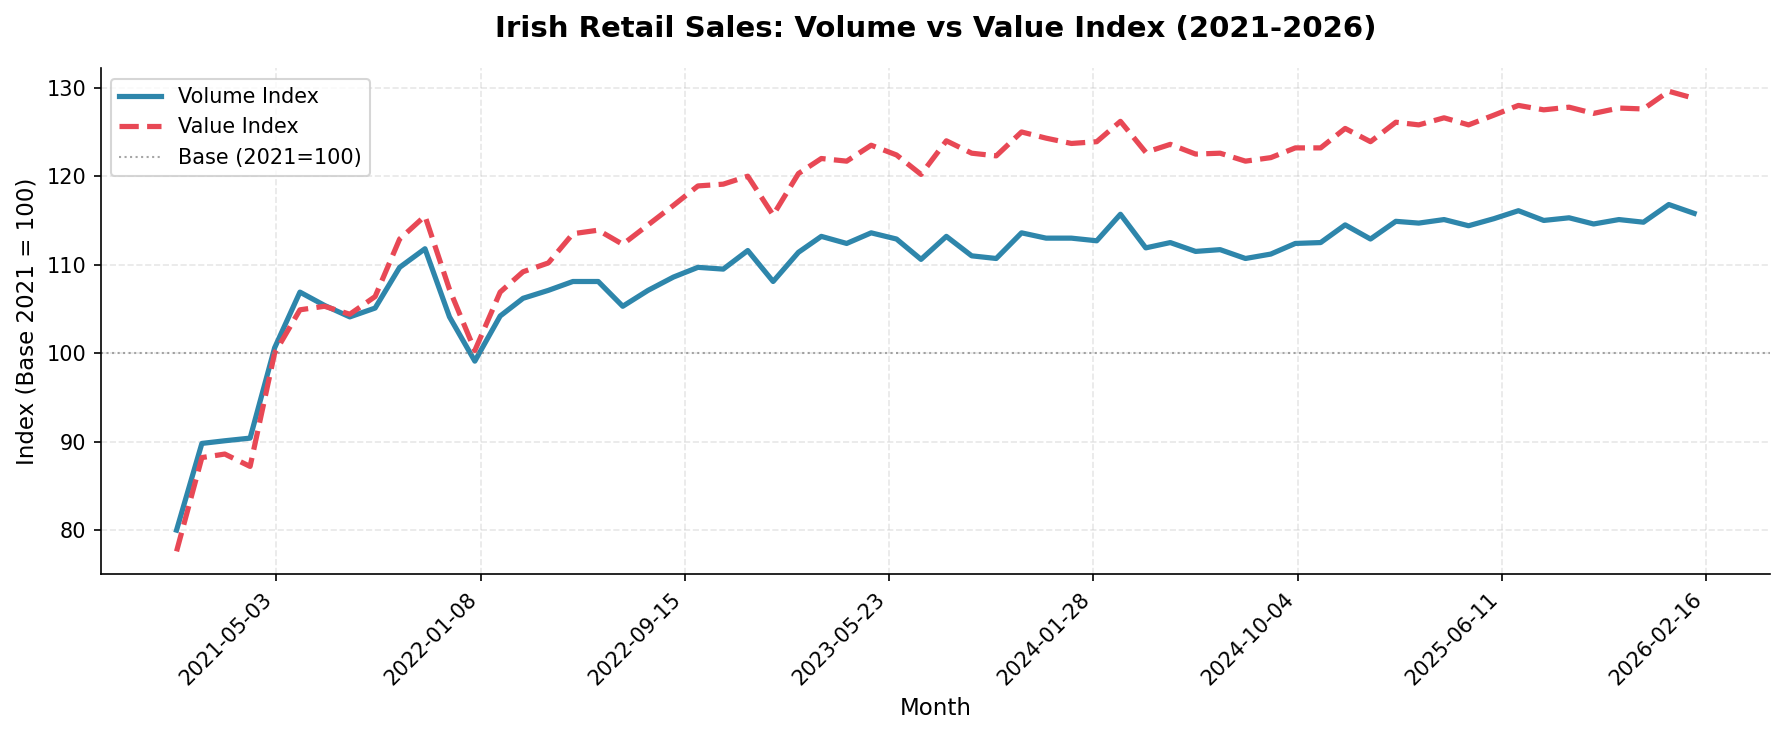

In [10]:
# Filter to all ratail only
all_retail = df[df['sector'] == 'All Retail'].sort_values('month')

# Create the figure
fig, ax = plt.subplots(figsize=(12, 5))

# Plot volume index
ax.plot(all_retail['month'], all_retail['volume_index'],
       color='#2E86AB', linewidth=2.5, label='Volume Index')

# Plot value index on the same chart for comparison
ax.plot(all_retail['month'], all_retail['value_index'],
       color='#E84855', linewidth=2.5, linestyle='--', label='Value Index')

# Add reference line at base year 100
ax.axhline(y=100, color='grey', linewidth=1, linestyle=':', alpha=0.7, label='Base (2021=100)')

# Labels and title
ax.set_title('Irish Retail Sales: Volume vs Value Index (2021-2026)',
            fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Index (Base 2021 = 100)', fontsize=11)
ax.legend(fontsize=10)

# Format x-axis to show year labels cleanly
ax.xaxis.set_major_locator(ticker.MaxNLocator(10))
fig.autofmt_xdate(rotation=45)

plt.tight_layout()
plt.savefig('chart1_overall_trend.png', bbox_inches='tight')
plt.show()                                                         

# Chart 2 — Sector performance heatmap
Which sectors grew or contracted in each year, and how does that compare across the full period?

In [11]:
# Exclude the All Retail aggregate - we want individual sectors only
sectors_only = df[df['sector'] != 'All Retail'].copy()

# Calculate year-on-year % change in volume for each sector
sectors_only = sectors_only.sort_values(['sector', 'month'])
sectors_only['yoy_volume'] = sectors_only.groupby('sector')['volume_index'].pct_change(12) * 100

# Add a year column
sectors_only['year'] = sectors_only['month'].dt.year

# Average YoY change per sector per year
heatmap_data = sectors_only.groupby(['sector', 'year'])['yoy_volume'].mean().reset_index()

# Pivot to wide format for heatmap
heatmap_pivot = heatmap_data.pivot(index='sector', columns='year', values='yoy_volume')

# Drop 2021 - no prior year data so it's all nulls
heatmap_pivot = heatmap_pivot.drop(columns=[2021], errors='ignore')

print(heatmap_pivot.round(1))

year                   2022  2023  2024  2025  2026
sector                                             
Automotive Fuel         3.3   5.2  -1.6  -0.6   2.5
Bars                  243.7   4.2  -3.1  -1.9   0.5
Books & Stationery     39.8  -0.1   2.0   0.4   4.1
Clothing & Footwear   119.2   1.0   4.9   0.5  -0.2
Department Stores      35.1  -6.4  -1.6  -1.6   0.5
Electrical Goods       -4.9  -2.7   0.7  -1.1  -0.0
Food Non-Specialised   -4.8   0.4  -0.2   1.7   0.7
Food Specialised      -11.7  -3.4  -1.4  -2.3  -2.4
Furniture & Lighting   12.9   8.1   2.5   2.9  -2.6
Hardware & Glass       -5.5   0.1   2.0   2.7   3.8
Motor Trades           -2.0  14.3   1.0   5.3   3.3
Other Retail           27.8   6.2   2.6   2.6   2.2
Pharmaceuticals         7.8   3.9  -0.5   2.2   4.1


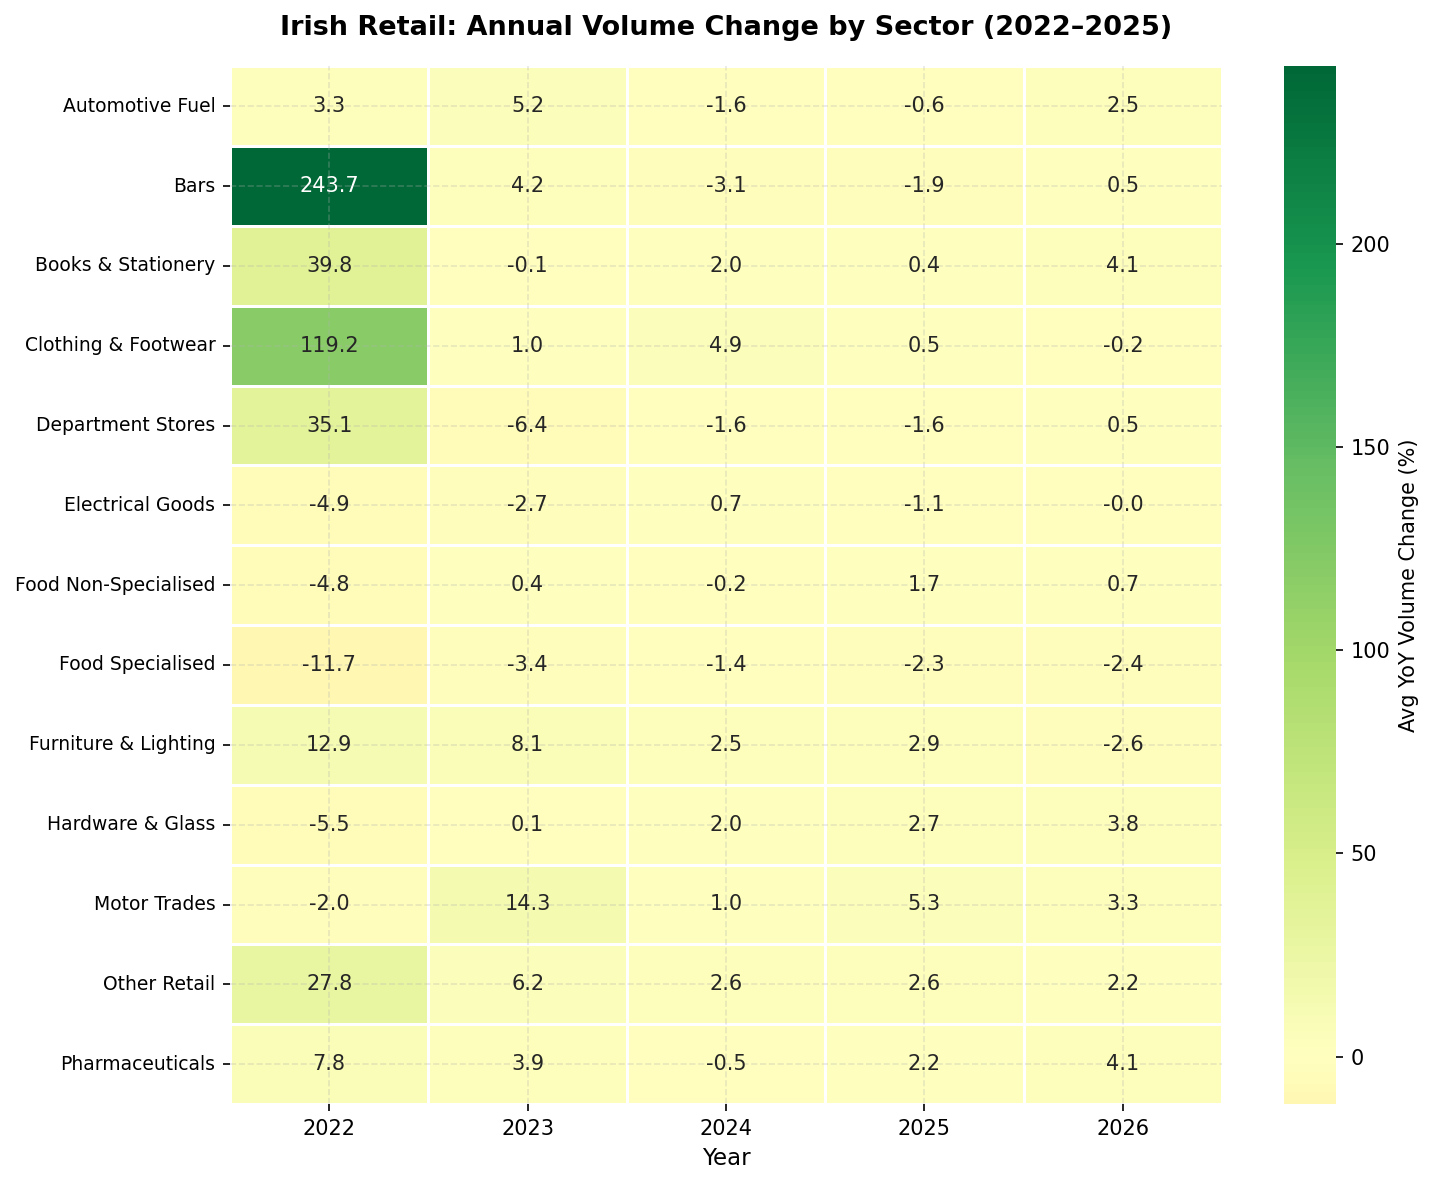

In [13]:
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    heatmap_pivot,
    annot=True,           # Show numbers inside cells
    fmt='.1f',            # One decimal place
    cmap='RdYlGn',        # Red = decline, Yellow = flat, Green = growth
    center=0,             # Centre the colour scale at zero
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Avg YoY Volume Change (%)'}
)

ax.set_title('Irish Retail: Annual Volume Change by Sector (2022–2025)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('')
ax.tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.savefig('chart2_sector_heatmap.png', bbox_inches='tight')
plt.show()

# Chart 3 — Winners and losers
Which sectors are genuinely ahead of where they started in 2021, and which are behind?

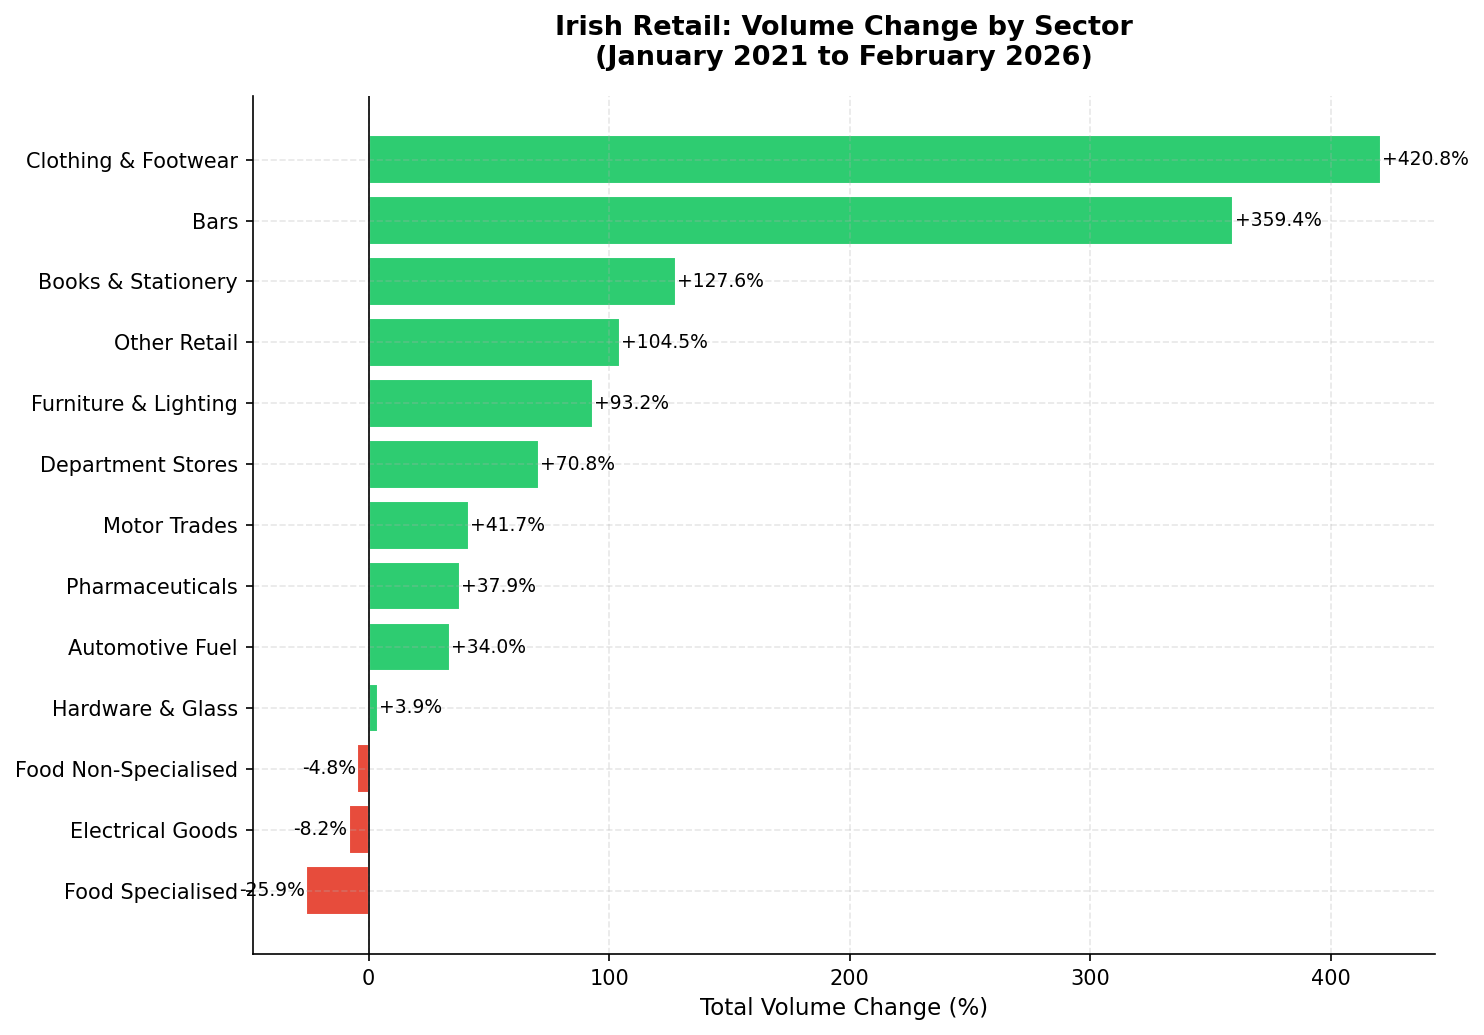

In [14]:
# Get first and latest volume index for each sector
first_month = df['month'].min()
last_month = df['month'].max()

start = df[df['month'] == first_month][['sector', 'volume_index']].rename(
    columns={'volume_index': 'start_index'})
end = df[df['month'] == last_month][['sector', 'volume_index']].rename(
    columns={'volume_index': 'end_index'})

# Merge and calculate % change from start to end
change_df = pd.merge(start, end, on='sector')
change_df['total_change'] = ((change_df['end_index'] - change_df['start_index']) 
                              / change_df['start_index'] * 100)

# Remove All Retail aggregate
change_df = change_df[change_df['sector'] != 'All Retail']

# Sort by change
change_df = change_df.sort_values('total_change', ascending=True)

# Assign colours - green for positive, red for negative
colours = ['#2ECC71' if x >= 0 else '#E74C3C' for x in change_df['total_change']]

# Plot
fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(change_df['sector'], change_df['total_change'], color=colours, edgecolor='white')

# Add value labels on bars
for bar, val in zip(bars, change_df['total_change']):
    x_pos = val + 0.5 if val >= 0 else val - 0.5
    ha = 'left' if val >= 0 else 'right'
    ax.text(x_pos, bar.get_y() + bar.get_height()/2,
            f'{val:+.1f}%', va='center', ha=ha, fontsize=9)

ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title(f'Irish Retail: Volume Change by Sector\n'
             f'({first_month.strftime("%B %Y")} to {last_month.strftime("%B %Y")})',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Total Volume Change (%)', fontsize=11)

plt.tight_layout()
plt.savefig('chart3_winners_losers.png', bbox_inches='tight')
plt.show()

# Chart 4 — Volume vs value scatter (the inflation lens)
During the 2022–2023 inflation period, which sectors had prices rising faster than real demand and which managed genuine volume growth?

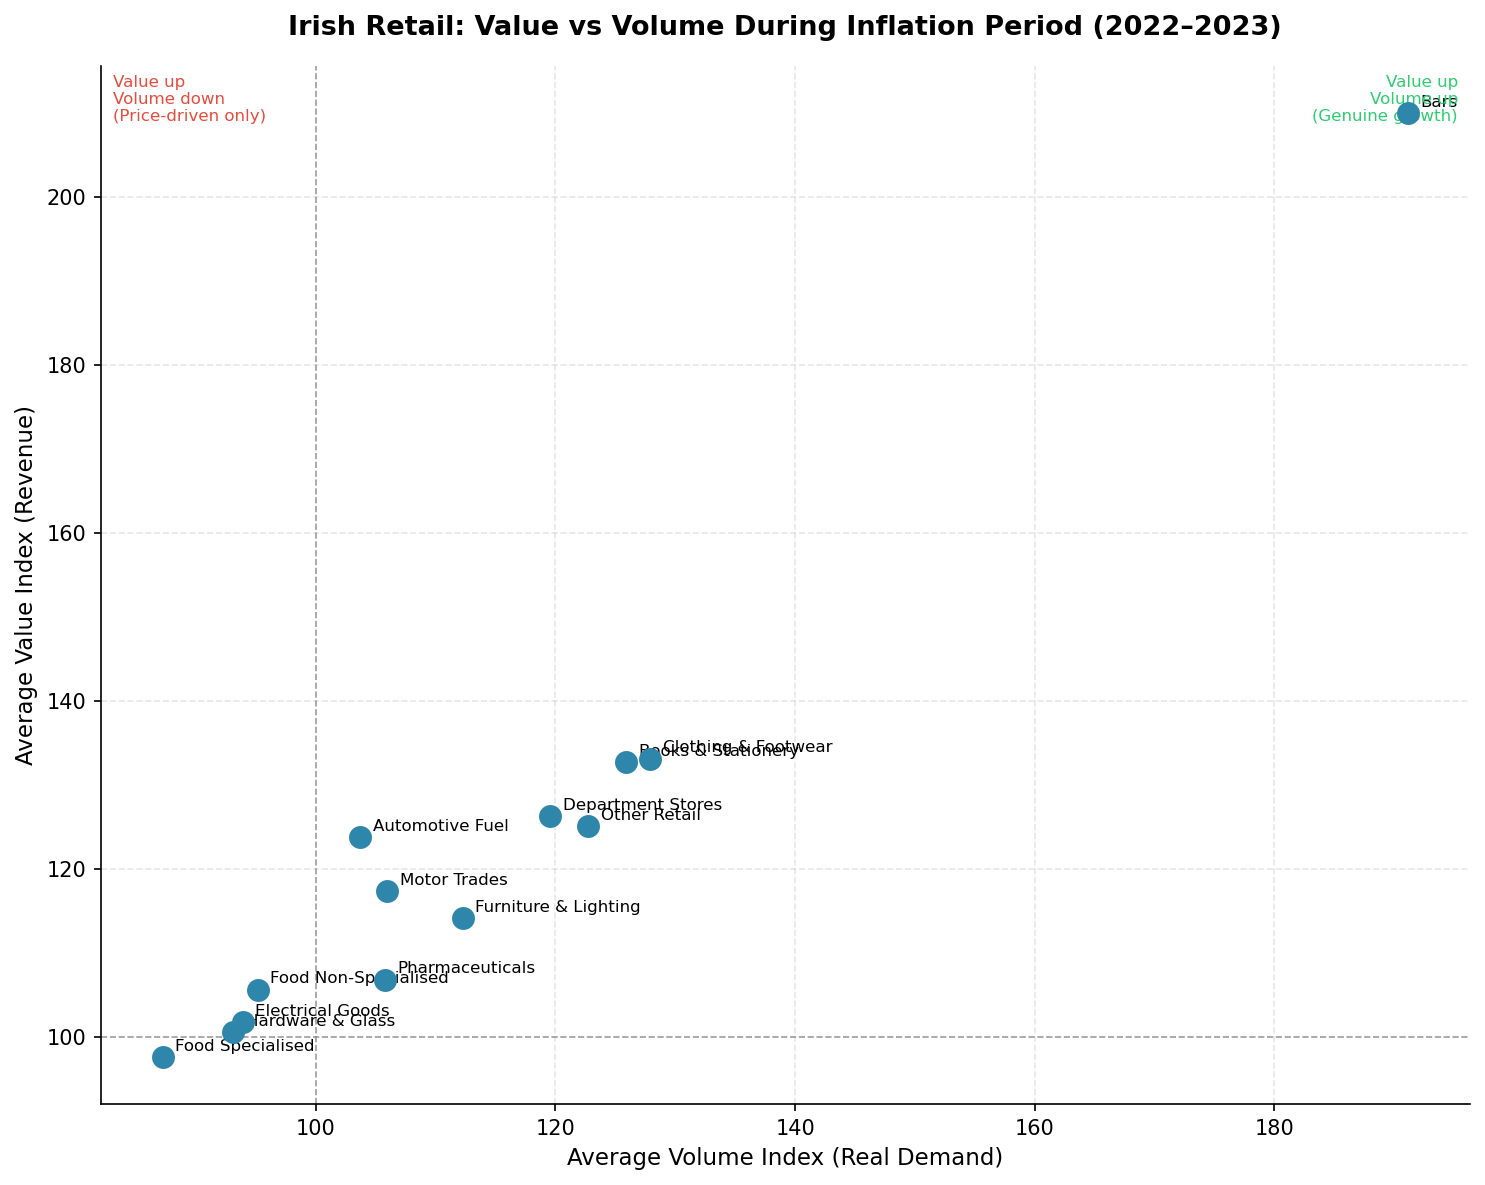

In [15]:
# Filter to the inflation window: 2022 and 2023
inflation_period = df[
    (df['month'].dt.year.isin([2022, 2023])) &
    (df['sector'] != 'All Retail')
]

# Average value and volume index during this period per sector
scatter_data = inflation_period.groupby('sector')[['value_index', 'volume_index']].mean().reset_index()

# Plot
fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(scatter_data['volume_index'], scatter_data['value_index'],
           color='#2E86AB', s=100, zorder=5)

# Label each point with sector name
for _, row in scatter_data.iterrows():
    ax.annotate(row['sector'],
                xy=(row['volume_index'], row['value_index']),
                xytext=(6, 3), textcoords='offset points',
                fontsize=8)

# Add reference lines at 100 (base year)
ax.axhline(y=100, color='grey', linewidth=0.8, linestyle='--', alpha=0.7)
ax.axvline(x=100, color='grey', linewidth=0.8, linestyle='--', alpha=0.7)

# Quadrant labels
ax.text(ax.get_xlim()[0] + 1, ax.get_ylim()[1] - 1,
        'Value up\nVolume down\n(Price-driven only)',
        fontsize=8, color='#E74C3C', va='top')
ax.text(ax.get_xlim()[1] - 1, ax.get_ylim()[1] - 1,
        'Value up\nVolume up\n(Genuine growth)',
        fontsize=8, color='#2ECC71', va='top', ha='right')

ax.set_title('Irish Retail: Value vs Volume During Inflation Period (2022–2023)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Average Volume Index (Real Demand)', fontsize=11)
ax.set_ylabel('Average Value Index (Revenue)', fontsize=11)

plt.tight_layout()
plt.savefig('chart4_inflation_scatter.png', bbox_inches='tight')
plt.show()

# Chart 5 — Seasonality
Which months are peak and trough for Clothing, Department Stores, and Bars and what should a business plan for?

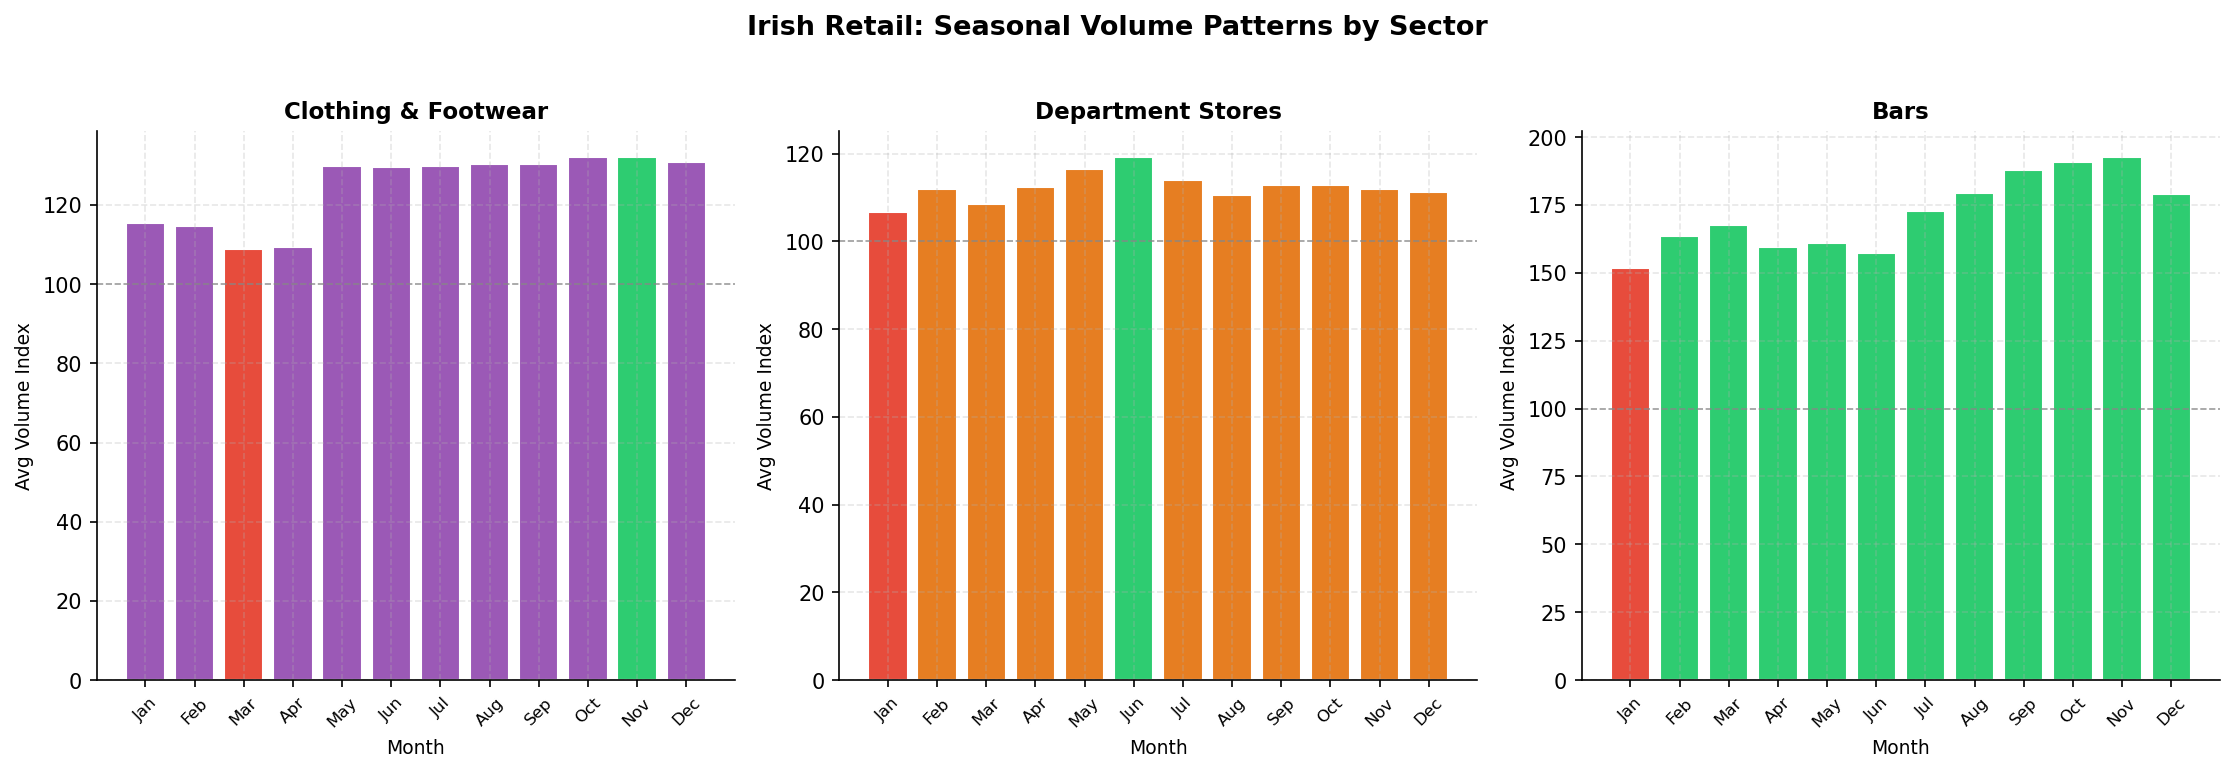

In [16]:
# Pick three sectors with clear seasonality
seasonal_sectors = ['Clothing & Footwear', 'Department Stores', 'Bars']

seasonal_df = df[df['sector'].isin(seasonal_sectors)].copy()
seasonal_df['month_num'] = seasonal_df['month'].dt.month
seasonal_df['month_name'] = seasonal_df['month'].dt.strftime('%b')

# Average volume index by sector and calendar month
seasonal_avg = seasonal_df.groupby(
    ['sector', 'month_num', 'month_name'])['volume_index'].mean().reset_index()
seasonal_avg = seasonal_avg.sort_values('month_num')

# Plot one panel per sector
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

colours_map = {
    'Clothing & Footwear': '#9B59B6',
    'Department Stores':   '#E67E22',
    'Bars':                '#2ECC71'
}

for ax, sector in zip(axes, seasonal_sectors):
    data = seasonal_avg[seasonal_avg['sector'] == sector]
    bar_colours = ['#E74C3C' if v == data['volume_index'].min()
                   else '#2ECC71' if v == data['volume_index'].max()
                   else colours_map[sector]
                   for v in data['volume_index']]

    ax.bar(data['month_name'], data['volume_index'],
           color=bar_colours, edgecolor='white')
    ax.axhline(y=100, color='grey', linewidth=0.8, linestyle='--', alpha=0.7)
    ax.set_title(sector, fontsize=11, fontweight='bold')
    ax.set_xlabel('Month', fontsize=9)
    ax.set_ylabel('Avg Volume Index', fontsize=9)
    ax.tick_params(axis='x', rotation=45, labelsize=8)

fig.suptitle('Irish Retail: Seasonal Volume Patterns by Sector',
             fontsize=13, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('chart5_seasonality.png', bbox_inches='tight')
plt.show()